# MLB Pitch Stuff Quality Score
### Interpretable "Stuff" Model using Statcast Data (2023–2025)

**Goal:** Build an explainable pitch-level *stuff score* — a weighted composite of velocity, movement, and spin — that predicts swing-and-miss and other outcomes. Show which physical characteristics drive stuff quality for each pitch type and each pitcher.

**Methodology:**
1. Pull 3 seasons of Statcast pitch data (2023–2025)
2. Engineer features: velocity, induced vertical break, horizontal break, spin rate, release extension, location
3. Fit an **interpretable logistic regression** predicting whiff probability per pitch
4. Derive a **Stuff+ score** (z-score normalized, 100 = league average)
5. Use **SHAP values** from a gradient boosted model to audit and deepen interpretability
6. Rank pitchers, show pitch-type breakdown, surface which components drive elite scores

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import shap

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, log_loss, average_precision_score
from sklearn.inspection import permutation_importance

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

DATA_DIR = 'data'
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [2]:
combined_path = os.path.join(DATA_DIR, 'statcast_2023_2025.parquet')

if not os.path.exists(combined_path):
    # Build from per-year files if combined not yet written
    frames = []
    for yr in [2023, 2024, 2025]:
        p = os.path.join(DATA_DIR, f'statcast_{yr}.parquet')
        if os.path.exists(p):
            df_yr = pd.read_parquet(p)
            df_yr['season'] = yr
            frames.append(df_yr)
            print(f'{yr}: {len(df_yr):,} pitches')
    raw = pd.concat(frames, ignore_index=True)
else:
    raw = pd.read_parquet(combined_path)

print(f'\nTotal pitches loaded: {len(raw):,}')
print(f'Seasons: {sorted(raw["season"].unique())}')
print(f'Columns: {list(raw.columns)}')


Total pitches loaded: 2,164,485
Seasons: [np.int64(2023), np.int64(2024), np.int64(2025)]
Columns: ['game_date', 'season', 'player_name', 'pitcher', 'batter', 'pitch_type', 'pitch_name', 'release_speed', 'release_spin_rate', 'pfx_x', 'pfx_z', 'plate_x', 'plate_z', 'release_extension', 'release_pos_x', 'release_pos_z', 'description', 'type', 'events', 'estimated_woba_using_speedangle', 'launch_speed', 'launch_angle', 'stand', 'p_throws', 'zone', 'balls', 'strikes', 'outs_when_up', 'inning']


## 2. Data Cleaning & Feature Engineering

**Key features:**
- `release_speed` — pitch velocity at release (mph)
- `pfx_z_in` — induced vertical break (inches, positive = rising)
- `pfx_x_in` — horizontal break (inches, arm-side positive for RHP)
- `release_spin_rate` — spin rate (rpm)
- `release_extension` — extension toward plate (ft)
- `plate_x`, `plate_z` — location at front of plate
- `velo_x_adj` — velocity adjusted for handedness (so same direction = same sign)

**Outcome labels:**
- `whiff` — 1 if swing-and-miss, 0 if other swing
- `chase` — 1 if swing on ball outside zone
- `csw` — called strike or whiff
- `xwoba` — expected wOBA on contact

In [3]:
df = raw.copy()

# --- convert pfx from feet to inches ---
df['pfx_x_in'] = pd.to_numeric(df['pfx_x'], errors='coerce') * 12
df['pfx_z_in'] = pd.to_numeric(df['pfx_z'], errors='coerce') * 12

# --- arm-side break: flip horizontal for LHP so positive = arm-side ---
df['break_arm'] = np.where(df['p_throws'] == 'L', -df['pfx_x_in'], df['pfx_x_in'])

# --- pitch velocity at plate (approx using extension) ---
df['extension'] = pd.to_numeric(df['release_extension'], errors='coerce').fillna(6.0)
df['perceived_velo'] = pd.to_numeric(df['release_speed'], errors='coerce') + (df['extension'] - 6.0) * 0.5

# --- outcomes (use fillna(False) before astype(int) to handle pandas 3.x nullable dtypes) ---
whiff_descs = {'swinging_strike', 'swinging_strike_blocked', 'foul_tip'}
swing_descs = whiff_descs | {
    'hit_into_play', 'foul', 'foul_bunt', 'missed_bunt'
}

df['is_swing'] = df['description'].isin(swing_descs).fillna(False).astype(int)
df['is_whiff'] = df['description'].isin(whiff_descs).fillna(False).astype(int)
df['is_csw']   = df['description'].isin(
    whiff_descs | {'called_strike'}
).fillna(False).astype(int)

# Chase: swing on a ball outside zone
zone_num = pd.to_numeric(df['zone'], errors='coerce')
df['in_zone']  = zone_num.between(1, 9).fillna(False)
df['is_chase'] = ((df['is_swing'] == 1) & (~df['in_zone'])).astype(int)

# Hard hit: launch speed >= 95 mph
launch = pd.to_numeric(df['launch_speed'], errors='coerce')
df['is_hard_hit'] = (launch >= 95).fillna(False).astype(int)
df['xwoba'] = pd.to_numeric(df['estimated_woba_using_speedangle'], errors='coerce')

# --- filter to meaningful pitch types ---
PITCH_TYPE_MAP = {
    'FF': 'Four-Seam FB',  'FA': 'Four-Seam FB',
    'SI': 'Sinker',        'FT': 'Sinker',
    'FC': 'Cutter',
    'SL': 'Slider',        'ST': 'Sweeper',
    'CU': 'Curveball',     'KC': 'Knuckle-Curve',
    'CH': 'Changeup',      'FS': 'Splitter',
    'SV': 'Slurve',
}
df['pitch_group'] = df['pitch_type'].map(PITCH_TYPE_MAP)
df = df[df['pitch_group'].notna()].copy()

# --- clean numerics ---
FEATURES = [
    'release_speed', 'pfx_x_in', 'pfx_z_in',
    'break_arm', 'release_spin_rate',
    'extension', 'perceived_velo',
    'plate_x', 'plate_z'
]
for c in FEATURES:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df_clean = df.dropna(subset=['release_speed', 'pfx_x_in', 'pfx_z_in',
                              'release_spin_rate', 'plate_x', 'plate_z']).copy()

# Remove extreme outliers (typos / tracking errors)
df_clean = df_clean[
    df_clean['release_speed'].between(50, 110) &
    df_clean['release_spin_rate'].between(500, 4000) &
    df_clean['pfx_z_in'].between(-30, 30) &
    df_clean['pfx_x_in'].between(-30, 30)
]

print(f'Clean pitch dataset: {len(df_clean):,} pitches')
print(f'Pitch groups: {df_clean["pitch_group"].value_counts().to_dict()}')
print(f'\nOverall whiff rate on swings: {df_clean["is_whiff"].sum() / df_clean["is_swing"].sum():.1%}')
print(f'Overall CSW rate: {df_clean["is_csw"].mean():.1%}')

Clean pitch dataset: 2,132,779 pitches
Pitch groups: {'Four-Seam FB': 686250, 'Sinker': 333274, 'Slider': 328185, 'Changeup': 223483, 'Cutter': 169723, 'Curveball': 141044, 'Sweeper': 140240, 'Splitter': 61508, 'Knuckle-Curve': 39487, 'Slurve': 9585}

Overall whiff rate on swings: 25.4%
Overall CSW rate: 28.5%


## 3. Baseline Outcome Rates by Pitch Type

In [4]:
# Per-pitch-type outcome summary
swings = df_clean[df_clean['is_swing'] == 1]

pitch_base = (
    df_clean.groupby('pitch_group')
    .agg(
        n_pitches=('is_swing', 'size'),
        csw_rate=('is_csw', 'mean'),
        avg_velo=('release_speed', 'mean'),
        avg_spin=('release_spin_rate', 'mean'),
        avg_ivb=('pfx_z_in', 'mean'),
        avg_hb=('pfx_x_in', 'mean'),
        avg_xwoba=('xwoba', 'mean')
    )
)
whiff_by_type = swings.groupby('pitch_group')['is_whiff'].mean().rename('whiff_rate')
pitch_summary = pitch_base.join(whiff_by_type).sort_values('n_pitches', ascending=False)

print('=== Pitch Type Outcomes (2023–2025) ===')
print(pitch_summary.to_string())

=== Pitch Type Outcomes (2023–2025) ===
               n_pitches  csw_rate  avg_velo  avg_spin  avg_ivb  avg_hb  avg_xwoba  whiff_rate
pitch_group                                                                                   
Four-Seam FB      686250     0.279    94.216  2298.372   15.755  -3.342      0.346       0.219
Sinker            333274     0.284    93.493  2161.880    7.616  -6.270      0.350       0.139
Slider            328185     0.310    85.750  2421.952    1.678   2.461      0.287       0.336
Changeup          223483     0.250    85.572  1794.731    5.163  -4.413      0.290       0.309
Cutter            169723     0.278    89.480  2400.219    7.943   1.473      0.342       0.233
Curveball         141044     0.312    79.358  2573.198   -9.846   4.232      0.279       0.310
Sweeper           140240     0.304    82.005  2569.599    1.223   7.254      0.265       0.317
Splitter           61508     0.253    86.556  1340.822    3.191  -9.426      0.258       0.343
Knuckle-Cu

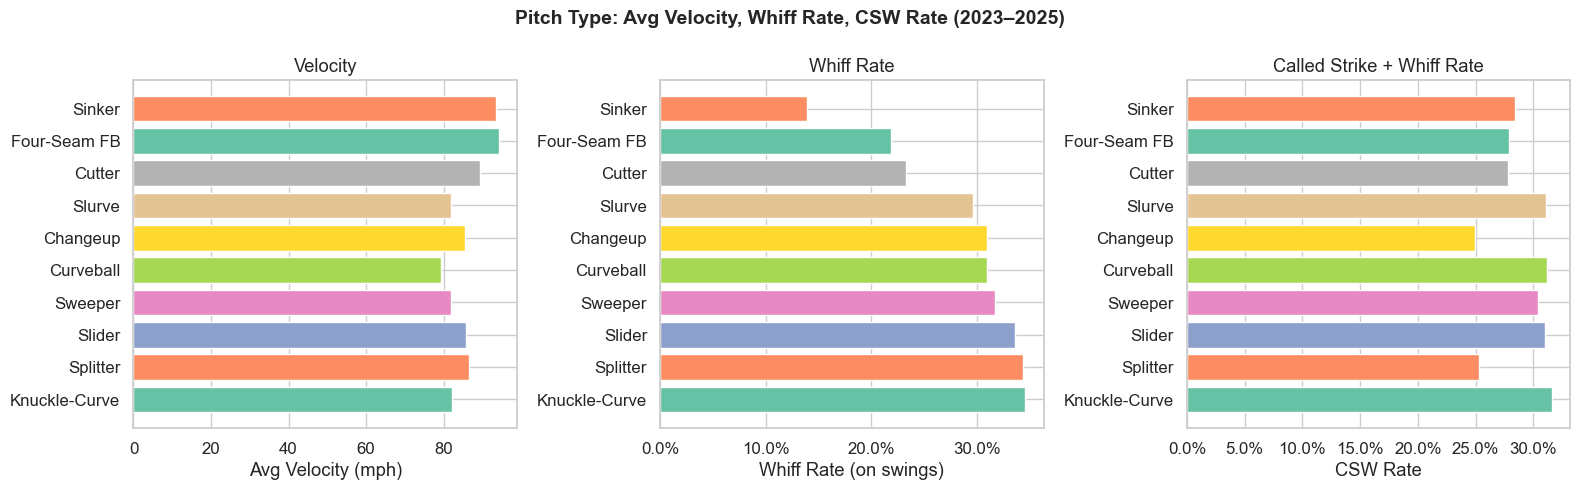

Saved: pitch_type_outcomes.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Pitch Type: Avg Velocity, Whiff Rate, CSW Rate (2023–2025)', fontsize=14, fontweight='bold')

ps = pitch_summary.reset_index().sort_values('whiff_rate', ascending=False)

colors = sns.color_palette('Set2', len(ps))

axes[0].barh(ps['pitch_group'], ps['avg_velo'], color=colors)
axes[0].set_xlabel('Avg Velocity (mph)')
axes[0].set_title('Velocity')

axes[1].barh(ps['pitch_group'], ps['whiff_rate'], color=colors)
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_xlabel('Whiff Rate (on swings)')
axes[1].set_title('Whiff Rate')

axes[2].barh(ps['pitch_group'], ps['csw_rate'], color=colors)
axes[2].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[2].set_xlabel('CSW Rate')
axes[2].set_title('Called Strike + Whiff Rate')

plt.tight_layout()
plt.savefig('pitch_type_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pitch_type_outcomes.png')

## 4. Stuff Score Model

### Design
We fit a **logistic regression** (L2-regularized) within each pitch type group to predict *whiff probability* on any given pitch. The model uses only physical characteristics — no count, game-state, or batter info — so it measures **pure pitch quality**.

Features used:
| Feature | Why it matters |
|---|---|
| `perceived_velo` | Higher perceived velocity → harder for hitter to time |
| `pfx_z_in` | Induced vertical break (rise on FB, drop on CB) |
| `break_arm` | Arm-side horizontal break (glove-side negative) |
| `release_spin_rate` | Spin → movement & deception |
| `extension` | Closer release point → shorter reaction time |
| `plate_x`, `plate_z` | Location — low/edge pitches generate more whiffs |

The predicted whiff probability is **z-score scaled** to a 100-point scale (mean = 100, SD = 10 → Stuff+).

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
import warnings

STUFF_FEATURES = [
    'perceived_velo', 'pfx_z_in', 'break_arm',
    'release_spin_rate', 'extension',
    'plate_x', 'plate_z'
]

# Only model on pitches that were swung at (whiff vs. contact)
swing_df = df_clean[df_clean['is_swing'] == 1].dropna(subset=STUFF_FEATURES).copy()
print(f'Swing subset for modeling: {len(swing_df):,} pitches')

models = {}       # pitch_group -> fitted pipeline
cv_aucs = {}      # pitch_group -> cross-val AUC
coef_dfs = []     # list of coef DataFrames

pitch_groups = swing_df['pitch_group'].value_counts()
pitch_groups = pitch_groups[pitch_groups >= 5000].index.tolist()  # need enough data

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for pg in pitch_groups:
    subset = swing_df[swing_df['pitch_group'] == pg]
    X = subset[STUFF_FEATURES].values
    y = subset['is_whiff'].values

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(C=1.0, max_iter=1000, random_state=42))
    ])

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        aucs = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
        pipe.fit(X, y)

    models[pg] = pipe
    cv_aucs[pg] = aucs.mean()

    # Extract coefficients (they're on the scaled feature space)
    coefs = pipe.named_steps['lr'].coef_[0]
    coef_df = pd.DataFrame({
        'feature': STUFF_FEATURES,
        'coefficient': coefs,
        'pitch_group': pg,
        'baseline_whiff': y.mean()
    })
    coef_dfs.append(coef_df)

    print(f'{pg:20s} | n={len(subset):>7,} | whiff%={y.mean():.1%} | AUC={aucs.mean():.3f} ± {aucs.std():.3f}')

coef_all = pd.concat(coef_dfs, ignore_index=True)
print(f'\nModels fitted for {len(models)} pitch groups.')

Swing subset for modeling: 1,018,578 pitches

Four-Seam FB         | n=333,845 | whiff%=21.9% | AUC=0.673 ± 0.002


Slider               | n=160,083 | whiff%=33.6% | AUC=0.735 ± 0.004


Sinker               | n=152,009 | whiff%=13.9% | AUC=0.542 ± 0.004


Changeup             | n=112,675 | whiff%=30.9% | AUC=0.697 ± 0.004
Cutter               | n= 83,764 | whiff%=23.3% | AUC=0.550 ± 0.005


Sweeper              | n= 63,801 | whiff%=31.7% | AUC=0.709 ± 0.008


Curveball            | n= 58,744 | whiff%=31.0% | AUC=0.779 ± 0.002
Splitter             | n= 32,018 | whiff%=34.3% | AUC=0.743 ± 0.007
Knuckle-Curve        | n= 17,559 | whiff%=34.6% | AUC=0.819 ± 0.005

Models fitted for 9 pitch groups.


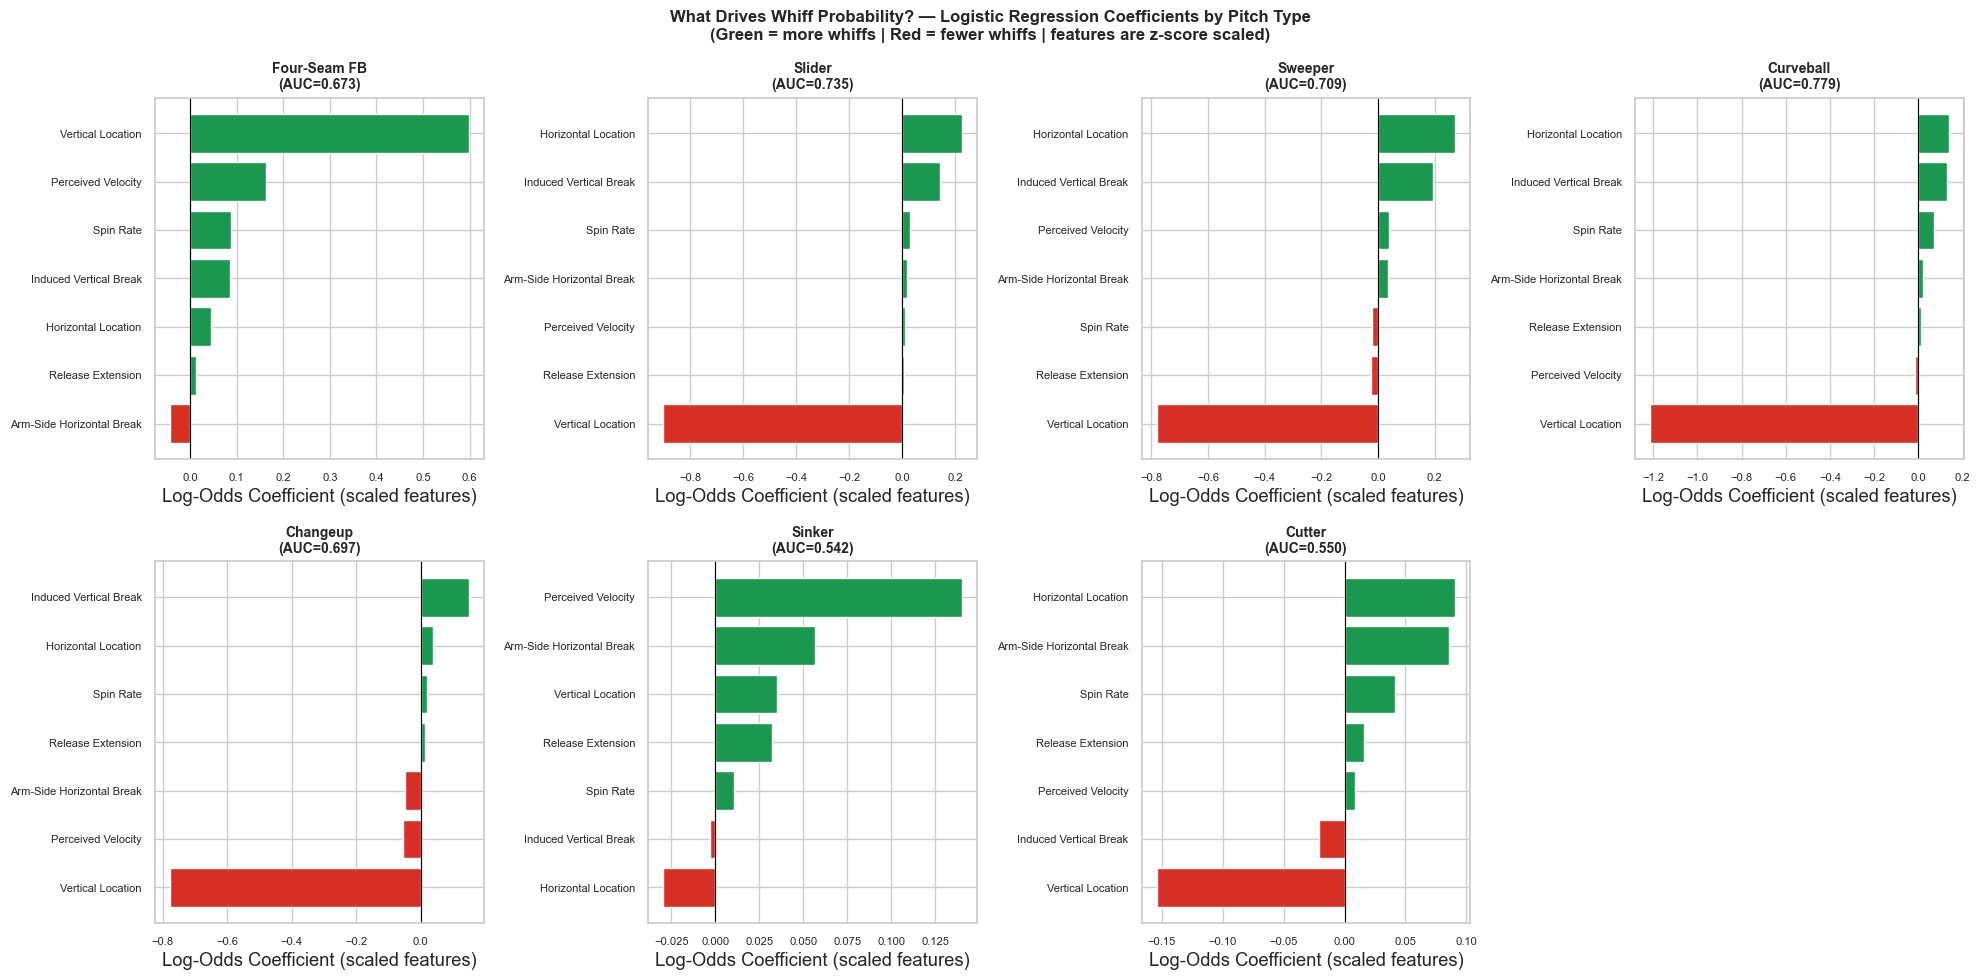

Saved: stuff_coefficients.png


In [7]:
# Visualize model coefficients — the "recipe" of the stuff score
FEATURE_LABELS = {
    'perceived_velo':     'Perceived Velocity',
    'pfx_z_in':           'Induced Vertical Break',
    'break_arm':          'Arm-Side Horizontal Break',
    'release_spin_rate':  'Spin Rate',
    'extension':          'Release Extension',
    'plate_x':            'Horizontal Location',
    'plate_z':            'Vertical Location'
}
coef_all['feature_label'] = coef_all['feature'].map(FEATURE_LABELS)

top_groups = [g for g in [
    'Four-Seam FB', 'Slider', 'Sweeper', 'Curveball', 'Changeup', 'Sinker', 'Cutter'
] if g in pitch_groups]

fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=False)
axes = axes.flatten()

for i, pg in enumerate(top_groups[:8]):
    ax = axes[i]
    sub = coef_all[coef_all['pitch_group'] == pg].sort_values('coefficient')
    colors = ['#d73027' if c < 0 else '#1a9850' for c in sub['coefficient']]
    ax.barh(sub['feature_label'], sub['coefficient'], color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{pg}\n(AUC={cv_aucs.get(pg, 0):.3f})', fontweight='bold', fontsize=10)
    ax.set_xlabel('Log-Odds Coefficient (scaled features)')
    ax.tick_params(labelsize=8)

for j in range(len(top_groups), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('What Drives Whiff Probability? — Logistic Regression Coefficients by Pitch Type\n'
             '(Green = more whiffs | Red = fewer whiffs | features are z-score scaled)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('stuff_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: stuff_coefficients.png')

## 5. Assign Stuff+ Score to Every Pitch

For each pitch we:
1. Get the model's predicted whiff probability
2. Z-score normalize across all pitches of that type → **Stuff+** (100 = avg, 110 = 1 SD above avg)

Scored 2,123,194 pitches

Stuff+ distribution:
count   2123194.000
mean        100.000
std          10.000
min          63.091
25%          92.236
50%          98.316
75%         106.296
max         191.467
Name: stuff_plus, dtype: float64


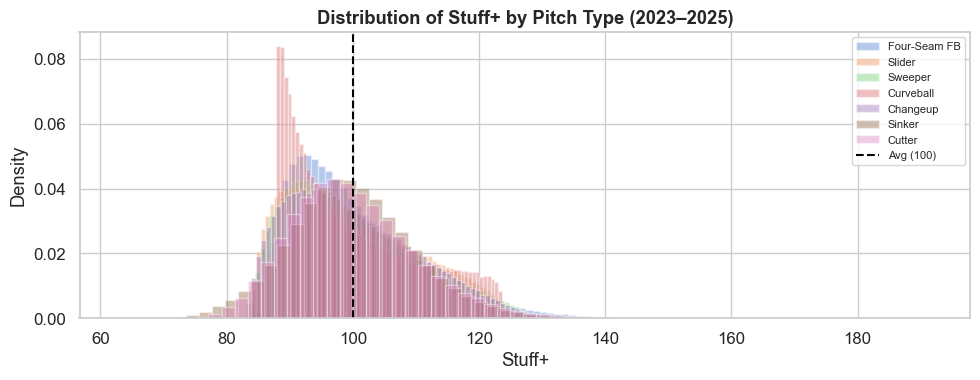

In [8]:
# Score ALL pitches (not just swings) so we get a per-pitch stuff score
all_model_df = df_clean[df_clean['pitch_group'].isin(pitch_groups)].dropna(subset=STUFF_FEATURES).copy()
all_model_df['stuff_prob'] = np.nan

for pg, pipe in models.items():
    mask = all_model_df['pitch_group'] == pg
    X = all_model_df.loc[mask, STUFF_FEATURES].values
    all_model_df.loc[mask, 'stuff_prob'] = pipe.predict_proba(X)[:, 1]

# Z-score within pitch group → Stuff+ (mean=100, sd=10)
def to_stuffplus(series):
    mu, sd = series.mean(), series.std()
    return 100 + 10 * (series - mu) / sd

all_model_df['stuff_plus'] = all_model_df.groupby('pitch_group')['stuff_prob'].transform(to_stuffplus)

print(f'Scored {len(all_model_df):,} pitches')
print(f'\nStuff+ distribution:')
print(all_model_df['stuff_plus'].describe())

fig, ax = plt.subplots(figsize=(10, 4))
for pg in top_groups:
    sub = all_model_df[all_model_df['pitch_group'] == pg]['stuff_plus']
    ax.hist(sub, bins=60, alpha=0.4, label=pg, density=True)
ax.axvline(100, color='black', linestyle='--', linewidth=1.5, label='Avg (100)')
ax.set_xlabel('Stuff+')
ax.set_ylabel('Density')
ax.set_title('Distribution of Stuff+ by Pitch Type (2023–2025)', fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('stuff_plus_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Stuff+ vs. Actual Outcomes

Validate the score: high Stuff+ should predict higher whiff rate, lower xwOBA, and higher CSW rate.

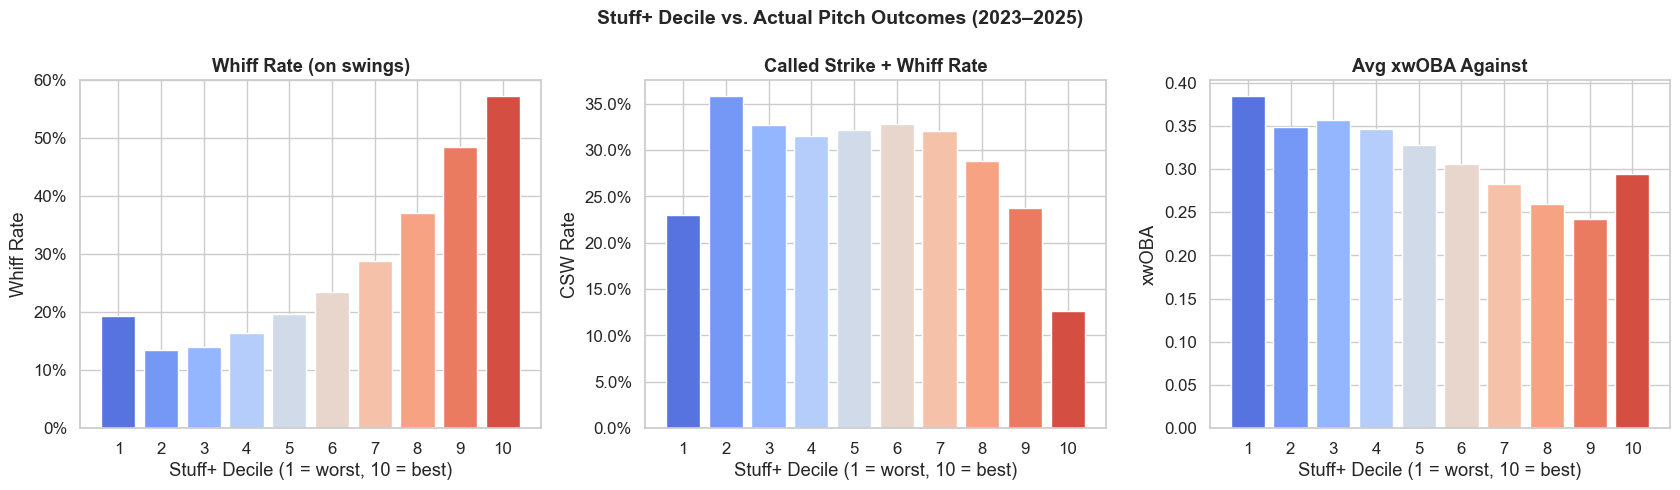

Outcome summary by Stuff+ decile:
 stuff_decile      n  avg_stuff_plus  whiff_rate  csw_rate  avg_xwoba
            1 212320          86.345       0.194     0.230      0.384
            2 212319          89.845       0.135     0.358      0.349
            3 212319          92.235       0.139     0.327      0.357
            4 212320          94.597       0.165     0.315      0.346
            5 212319          97.043       0.197     0.321      0.328
            6 212319          99.692       0.235     0.327      0.306
            7 212320         102.701       0.289     0.320      0.283
            8 212319         106.337       0.371     0.288      0.260
            9 212319         111.176       0.485     0.237      0.242
           10 212320         120.028       0.572     0.126      0.294


In [9]:
# Bin into Stuff+ deciles and compute actual outcomes
all_model_df['stuff_decile'] = (
    pd.qcut(all_model_df['stuff_plus'], q=10, labels=False, duplicates='drop')
    .astype(float).fillna(0).astype(int) + 1
)

swing_scored = all_model_df[all_model_df['is_swing'] == 1]

decile_base = (
    all_model_df.groupby('stuff_decile')
    .agg(
        n=('is_swing', 'size'),
        csw_rate=('is_csw', 'mean'),
        avg_xwoba=('xwoba', 'mean'),
        avg_stuff_plus=('stuff_plus', 'mean')
    )
)
decile_whiff = swing_scored.groupby('stuff_decile')['is_whiff'].mean().rename('whiff_rate')
decile_outcomes = decile_base.join(decile_whiff).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Stuff+ Decile vs. Actual Pitch Outcomes (2023–2025)', fontsize=14, fontweight='bold')

palette = sns.color_palette('coolwarm', 10)

for ax, (col, ylabel, title) in zip(axes, [
    ('whiff_rate',  'Whiff Rate',  'Whiff Rate (on swings)'),
    ('csw_rate',    'CSW Rate',    'Called Strike + Whiff Rate'),
    ('avg_xwoba',   'xwOBA',       'Avg xwOBA Against')
]):
    bars = ax.bar(decile_outcomes['stuff_decile'], decile_outcomes[col],
                  color=palette, edgecolor='white')
    ax.set_xlabel('Stuff+ Decile (1 = worst, 10 = best)')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(range(1, 11))
    if col != 'avg_xwoba':
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig('stuff_plus_vs_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()

print('Outcome summary by Stuff+ decile:')
print(decile_outcomes[['stuff_decile', 'n', 'avg_stuff_plus', 'whiff_rate', 'csw_rate', 'avg_xwoba']].to_string(index=False))

## 7. Pitcher-Level Stuff+ Rankings

Aggregate pitch-level scores to pitcher level (weighted by pitch usage).

Qualified pitchers (>=200 pitches per season): 1912


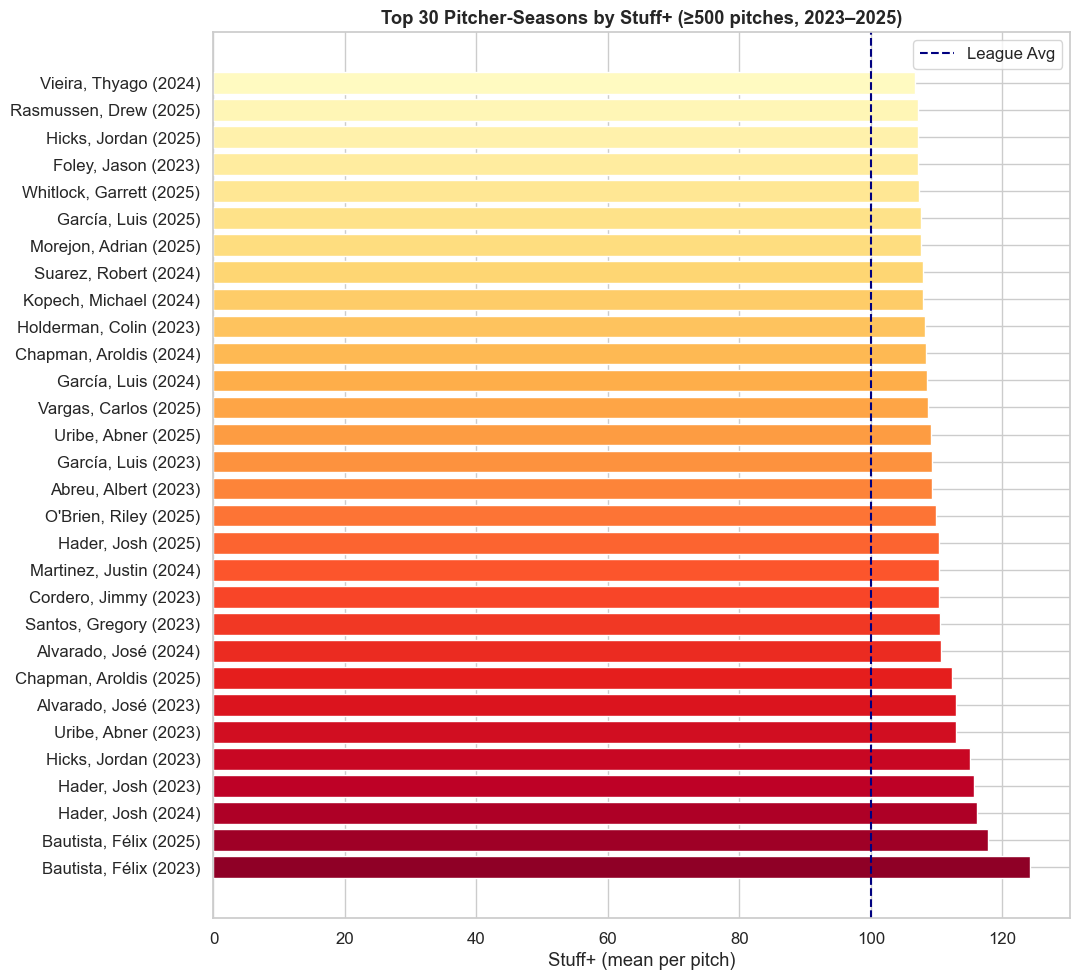


Top 20 pitcher-seasons:
     player_name  season  n_pitches  stuff_plus_mean  whiff_rate  csw_rate  avg_velo  avg_xwoba
 Bautista, Félix    2023        977          124.135       0.440     0.366    96.194      0.225
 Bautista, Félix    2025        626          117.765       0.357     0.302    93.742      0.264
     Hader, Josh    2024       1153          116.161       0.404     0.343    93.154      0.262
     Hader, Josh    2023       1020          115.615       0.335     0.301    93.436      0.235
   Hicks, Jordan    2023       1084          115.071       0.286     0.320    96.824      0.285
    Uribe, Abner    2023        518          112.952       0.329     0.322    96.229      0.291
  Alvarado, José    2023        742          112.898       0.335     0.321    96.369      0.259
Chapman, Aroldis    2025        917          112.322       0.356     0.333    96.145      0.225
  Alvarado, José    2024       1038          110.706       0.284     0.286    95.622      0.310
 Santos, Gregor

In [10]:
# Pitcher-level aggregation
pitcher_agg = (
    all_model_df.groupby(['pitcher', 'player_name', 'season'])
    .agg(
        n_pitches=('stuff_plus', 'size'),
        stuff_plus_mean=('stuff_plus', 'mean'),
        csw_rate=('is_csw', 'mean'),
        avg_velo=('release_speed', 'mean'),
        avg_spin=('release_spin_rate', 'mean'),
        avg_ivb=('pfx_z_in', 'mean'),
        avg_hb=('pfx_x_in', 'mean'),
        avg_xwoba=('xwoba', 'mean')
    )
    .reset_index()
)

# Whiff rate (only on swings)
pitcher_whiff = (
    all_model_df[all_model_df['is_swing'] == 1]
    .groupby(['pitcher', 'season'])
    .agg(whiff_rate=('is_whiff', 'mean'), n_swings=('is_whiff', 'size'))
    .reset_index()
)
pitcher_agg = pitcher_agg.merge(pitcher_whiff, on=['pitcher', 'season'], how='left')

# Minimum 200 pitches for reliable estimates
pitcher_qual = pitcher_agg[pitcher_agg['n_pitches'] >= 200].copy()

print(f'Qualified pitchers (>=200 pitches per season): {len(pitcher_qual)}')

# ---- All-season best stuff
best_stuff = (
    pitcher_agg[pitcher_agg['n_pitches'] >= 500]
    .sort_values('stuff_plus_mean', ascending=False)
    .head(30)
)

fig, ax = plt.subplots(figsize=(11, 10))
bars = ax.barh(
    best_stuff['player_name'] + ' (' + best_stuff['season'].astype(str) + ')',
    best_stuff['stuff_plus_mean'],
    color=sns.color_palette('YlOrRd', 30)[::-1],
    edgecolor='white'
)
ax.axvline(100, color='navy', linestyle='--', linewidth=1.5, label='League Avg')
ax.set_xlabel('Stuff+ (mean per pitch)')
ax.set_title('Top 30 Pitcher-Seasons by Stuff+ (≥500 pitches, 2023–2025)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('top_pitchers_stuff.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 20 pitcher-seasons:')
print(best_stuff[['player_name', 'season', 'n_pitches', 'stuff_plus_mean',
                   'whiff_rate', 'csw_rate', 'avg_velo', 'avg_xwoba']].head(20).to_string(index=False))

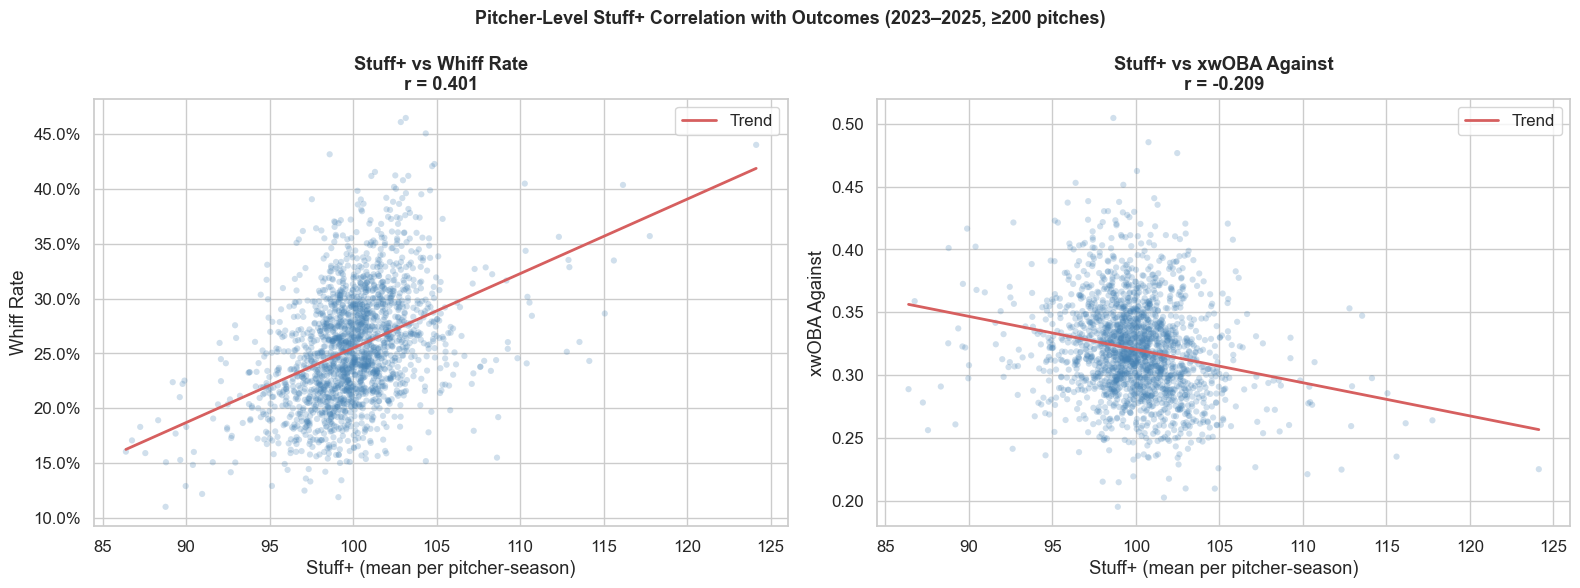

In [11]:
# Scatter: Stuff+ vs Whiff Rate (pitcher-season level)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Pitcher-Level Stuff+ Correlation with Outcomes (2023–2025, ≥200 pitches)',
             fontsize=13, fontweight='bold')

for ax, (y_col, ylabel, title) in zip(axes, [
    ('whiff_rate', 'Whiff Rate', 'Stuff+ vs Whiff Rate'),
    ('avg_xwoba',  'xwOBA Against', 'Stuff+ vs xwOBA Against')
]):
    sub = pitcher_qual.dropna(subset=[y_col])
    ax.scatter(sub['stuff_plus_mean'], sub[y_col],
               alpha=0.25, s=20, color='steelblue', edgecolors='none')

    # Trend line
    z = np.polyfit(sub['stuff_plus_mean'], sub[y_col], 1)
    p = np.poly1d(z)
    xs = np.linspace(sub['stuff_plus_mean'].min(), sub['stuff_plus_mean'].max(), 100)
    ax.plot(xs, p(xs), 'r-', linewidth=2, label='Trend')

    corr = sub['stuff_plus_mean'].corr(sub[y_col])
    ax.set_xlabel('Stuff+ (mean per pitcher-season)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title}\nr = {corr:.3f}', fontweight='bold')
    ax.legend()
    if y_col == 'whiff_rate':
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig('pitcher_stuff_vs_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. SHAP Explainability

A gradient-boosted model can capture nonlinear effects (e.g., velocity matters more at 99+ mph than at 92). We use **SHAP values** to explain *which feature contributed how much* to each pitch's Stuff+ score — making the nonlinear model interpretable at the pitch and pitcher level.

In [12]:
from sklearn.ensemble import GradientBoostingClassifier

# Focus on Four-Seam FB for SHAP deep-dive (most common pitch, clearest physics)
FOCUS_PITCH = 'Four-Seam FB'

fb_swings = swing_df[swing_df['pitch_group'] == FOCUS_PITCH].dropna(subset=STUFF_FEATURES).copy()

# Sample for speed if needed
SAMPLE_SIZE = min(80_000, len(fb_swings))
fb_sample = fb_swings.sample(n=SAMPLE_SIZE, random_state=42)

X_fb = fb_sample[STUFF_FEATURES].values
y_fb = fb_sample['is_whiff'].values

scaler_fb = StandardScaler()
X_fb_scaled = scaler_fb.fit_transform(X_fb)

gbc = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42, min_samples_leaf=50
)
print('Training GBM for SHAP analysis...')
gbc.fit(X_fb_scaled, y_fb)

cv_auc_gbc = cross_val_score(gbc, X_fb_scaled, y_fb,
                              cv=StratifiedKFold(5, shuffle=True, random_state=42),
                              scoring='roc_auc').mean()
print(f'GBM AUC ({FOCUS_PITCH}): {cv_auc_gbc:.3f}  (vs LR: {cv_aucs.get(FOCUS_PITCH, 0):.3f})')

Training GBM for SHAP analysis...


GBM AUC (Four-Seam FB): 0.679  (vs LR: 0.673)


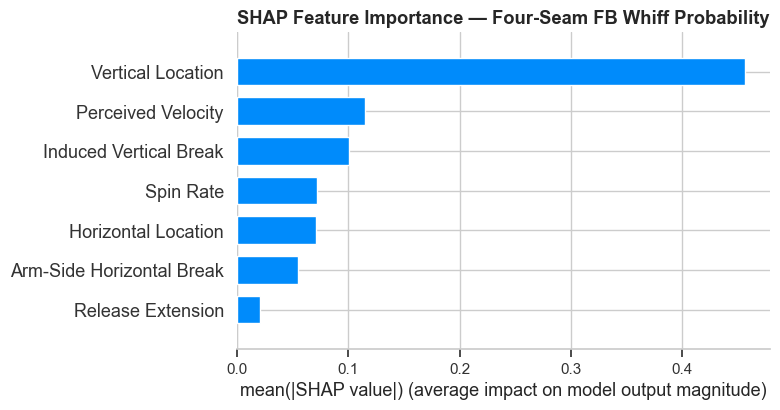

Saved: shap_bar_4seam.png


In [13]:
# SHAP values
explainer = shap.TreeExplainer(gbc)

# Use a representative subsample for SHAP plots
shap_sample = fb_sample.sample(n=min(10_000, len(fb_sample)), random_state=1)
X_shap = scaler_fb.transform(shap_sample[STUFF_FEATURES].values)
shap_values = explainer.shap_values(X_shap)

feature_labels_list = [FEATURE_LABELS[f] for f in STUFF_FEATURES]

# Summary bar plot
fig, ax = plt.subplots(figsize=(9, 5))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=feature_labels_list,
    plot_type='bar',
    show=False
)
plt.title(f'SHAP Feature Importance — {FOCUS_PITCH} Whiff Probability', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar_4seam.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_bar_4seam.png')

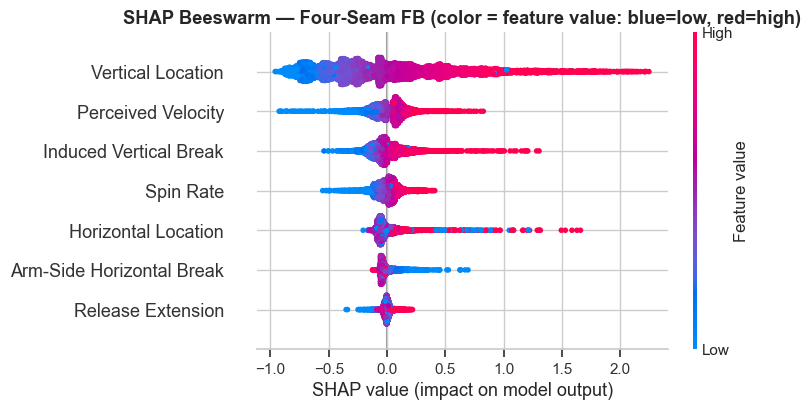

Saved: shap_beeswarm_4seam.png


In [14]:
# SHAP beeswarm: shows direction AND magnitude of each feature's effect
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=feature_labels_list,
    show=False,
    max_display=7
)
plt.title(f'SHAP Beeswarm — {FOCUS_PITCH} (color = feature value: blue=low, red=high)',
          fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm_4seam.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_beeswarm_4seam.png')

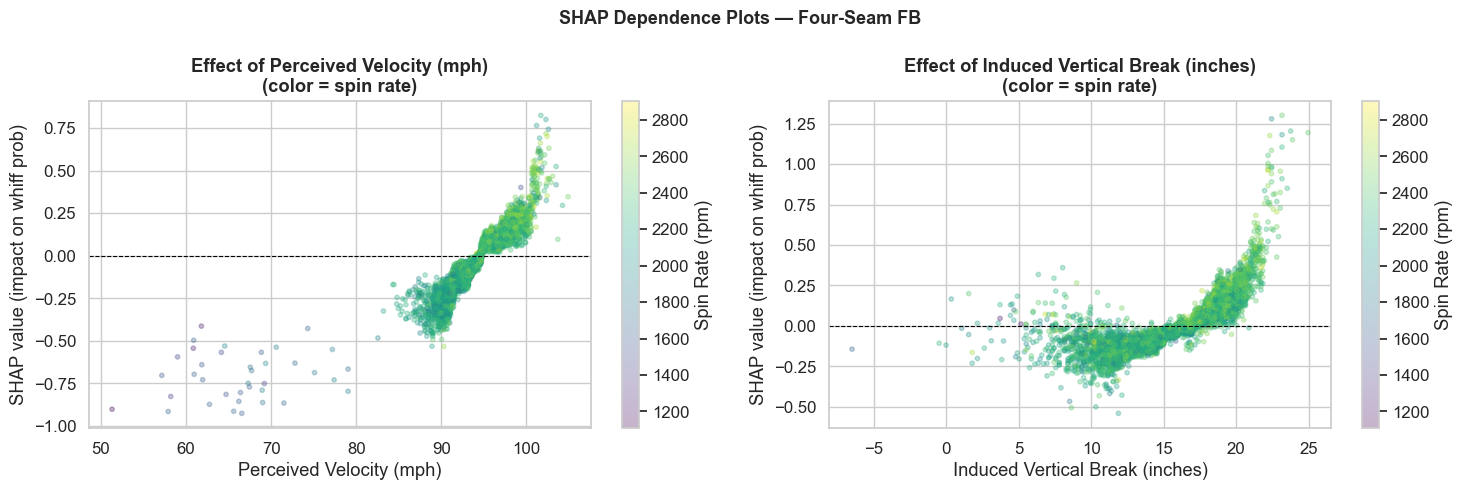

Saved: shap_dependence_4seam.png


In [15]:
# SHAP dependence plots: velocity and IVB
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'SHAP Dependence Plots — {FOCUS_PITCH}', fontsize=13, fontweight='bold')

feat_idx = {f: i for i, f in enumerate(STUFF_FEATURES)}
orig_values = shap_sample[STUFF_FEATURES].values  # unscaled for axis labels

for ax, (feat, label) in zip(axes, [
    ('perceived_velo', 'Perceived Velocity (mph)'),
    ('pfx_z_in',       'Induced Vertical Break (inches)')
]):
    idx = feat_idx[feat]
    sc = ax.scatter(
        orig_values[:, idx],
        shap_values[:, idx],
        c=orig_values[:, feat_idx['release_spin_rate']],
        cmap='viridis', alpha=0.3, s=10
    )
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel(label)
    ax.set_ylabel(f'SHAP value (impact on whiff prob)')
    ax.set_title(f'Effect of {label}\n(color = spin rate)', fontweight='bold')
    plt.colorbar(sc, ax=ax, label='Spin Rate (rpm)')

plt.tight_layout()
plt.savefig('shap_dependence_4seam.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_dependence_4seam.png')

## 9. Pitcher Component Breakdown

For each pitcher, decompose their Stuff+ score into contributions from each feature using SHAP — making it clear *why* a pitcher is elite or below average.

In [16]:
# Score all 4-seam fastballs with GBM + compute mean SHAP per pitcher
fb_all = all_model_df[
    (all_model_df['pitch_group'] == FOCUS_PITCH)
].dropna(subset=STUFF_FEATURES).copy()

# Only pitchers with enough 4-seamers
pitcher_counts = fb_all.groupby('pitcher').size()
qual_pitchers = pitcher_counts[pitcher_counts >= 300].index
fb_qual = fb_all[fb_all['pitcher'].isin(qual_pitchers)].copy()

X_all = scaler_fb.transform(fb_qual[STUFF_FEATURES].values)
shap_all = explainer.shap_values(X_all)

# Add SHAP columns to dataframe
for i, f in enumerate(STUFF_FEATURES):
    fb_qual[f'shap_{f}'] = shap_all[:, i]

shap_cols = [f'shap_{f}' for f in STUFF_FEATURES]

# Mean SHAP per pitcher (most recent season)
max_season = fb_qual['season'].max()
fb_recent = fb_qual[fb_qual['season'] == max_season]

pitcher_shap = (
    fb_recent.groupby(['pitcher', 'player_name'])
    .agg({**{c: 'mean' for c in shap_cols},
          'stuff_plus': 'mean',
          'release_speed': 'size'})
    .rename(columns={'release_speed': 'n_pitches'})
    .reset_index()
)
pitcher_shap.columns = (
    list(pitcher_shap.columns[:2]) +
    [f.replace('shap_', '') for f in shap_cols] +
    ['stuff_plus', 'n_pitches']
)
pitcher_shap = pitcher_shap[pitcher_shap['n_pitches'] >= 150].copy()

# Top 15 and bottom 15 by Stuff+
top15 = pitcher_shap.nlargest(15, 'stuff_plus')
bot15 = pitcher_shap.nsmallest(15, 'stuff_plus')
showcase = pd.concat([top15, bot15])

print(f'Pitcher SHAP breakdown ready: {len(pitcher_shap)} pitchers in {max_season}')

Pitcher SHAP breakdown ready: 379 pitchers in 2025


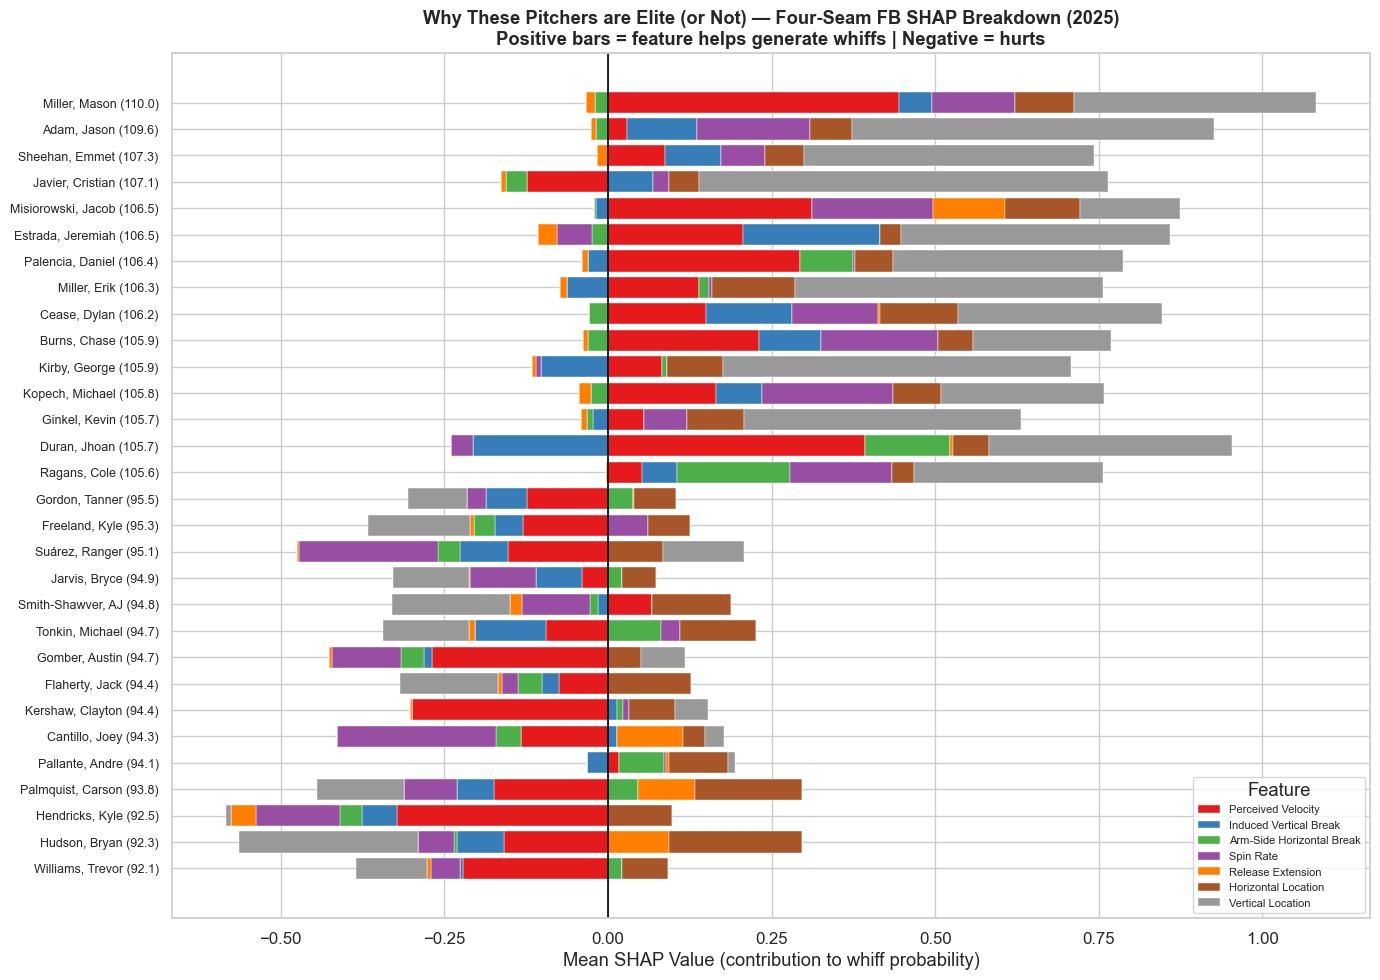

Saved: pitcher_shap_breakdown.png


In [17]:
# Stacked bar chart: SHAP breakdown for top/bottom pitchers
feature_nice = [
    'perceived_velo', 'pfx_z_in', 'break_arm',
    'release_spin_rate', 'extension', 'plate_x', 'plate_z'
]
label_nice = [FEATURE_LABELS[f] for f in feature_nice]
colors_nice = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628','#999999']

fig, ax = plt.subplots(figsize=(14, 10))

showcase_sorted = showcase.sort_values('stuff_plus', ascending=True)
y_pos = np.arange(len(showcase_sorted))
y_labels = showcase_sorted['player_name'] + ' (' + showcase_sorted['stuff_plus'].round(1).astype(str) + ')'

cum_pos = np.zeros(len(showcase_sorted))
cum_neg = np.zeros(len(showcase_sorted))

for feat, label, color in zip(feature_nice, label_nice, colors_nice):
    vals = showcase_sorted[feat].values
    pos_vals = np.where(vals >= 0, vals, 0)
    neg_vals = np.where(vals < 0, vals, 0)
    ax.barh(y_pos, pos_vals, left=cum_pos, color=color, label=label, height=0.8, edgecolor='white', lw=0.3)
    ax.barh(y_pos, neg_vals, left=cum_neg, color=color, height=0.8, edgecolor='white', lw=0.3)
    cum_pos += pos_vals
    cum_neg += neg_vals

ax.axvline(0, color='black', linewidth=1.2)
ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels, fontsize=9)
ax.set_xlabel('Mean SHAP Value (contribution to whiff probability)')
ax.set_title(
    f'Why These Pitchers are Elite (or Not) — {FOCUS_PITCH} SHAP Breakdown ({max_season})\n'
    'Positive bars = feature helps generate whiffs | Negative = hurts',
    fontweight='bold'
)
ax.legend(loc='lower right', fontsize=8, title='Feature')
plt.tight_layout()
plt.savefig('pitcher_shap_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pitcher_shap_breakdown.png')

## 10. Pitch Arsenal Stuff Score

A pitcher's overall arsenal stuff score is the **usage-weighted average** Stuff+ across all pitch types.

In [18]:
# Arsenal-level stuff score
arsenal = (
    all_model_df[all_model_df['season'] == max_season]
    .groupby(['pitcher', 'player_name', 'pitch_group'])
    .agg(
        n=('stuff_plus', 'size'),
        stuff_plus=('stuff_plus', 'mean'),
        whiff_rate=('is_whiff', 'mean'),
        avg_velo=('release_speed', 'mean')
    )
    .reset_index()
)

# Weighted average by usage (avoid apply for pandas 3.x compatibility)
arsenal['weighted'] = arsenal['n'] * arsenal['stuff_plus']
arsenal_overall = (
    arsenal.groupby(['pitcher', 'player_name'])
    .agg(weighted_sum=('weighted', 'sum'), total_n=('n', 'sum'))
    .reset_index()
)
arsenal_overall['arsenal_stuff'] = arsenal_overall['weighted_sum'] / arsenal_overall['total_n']
arsenal_overall = arsenal_overall.drop(columns=['weighted_sum', 'total_n'])
arsenal_counts = arsenal.groupby('pitcher')['n'].sum().reset_index(name='total_pitches')
arsenal_overall = arsenal_overall.merge(arsenal_counts, on='pitcher')

# Merge with outcomes
season_outcomes = (
    all_model_df[all_model_df['season'] == max_season]
    .groupby('pitcher')
    .agg(csw_rate=('is_csw', 'mean'), avg_xwoba=('xwoba', 'mean'))
    .reset_index()
)
season_whiff = (
    all_model_df[(all_model_df['season'] == max_season) & (all_model_df['is_swing'] == 1)]
    .groupby('pitcher')
    .agg(whiff_rate=('is_whiff', 'mean'))
    .reset_index()
)
arsenal_overall = (
    arsenal_overall
    .merge(season_outcomes, on='pitcher', how='left')
    .merge(season_whiff, on='pitcher', how='left')
)

qual_arsenal = arsenal_overall[arsenal_overall['total_pitches'] >= 500].copy()

print(f'Arsenal stuff scores: {len(qual_arsenal)} qualified pitchers in {max_season}')
print('\nTop 20 by Arsenal Stuff+:')
print(
    qual_arsenal.sort_values('arsenal_stuff', ascending=False)
    [['player_name', 'total_pitches', 'arsenal_stuff', 'whiff_rate', 'csw_rate', 'avg_xwoba']]
    .head(20)
    .to_string(index=False)
)

Arsenal stuff scores: 475 qualified pitchers in 2025

Top 20 by Arsenal Stuff+:
      player_name  total_pitches  arsenal_stuff  whiff_rate  csw_rate  avg_xwoba
  Bautista, Félix            626        117.765       0.357     0.302      0.264
 Chapman, Aroldis            917        112.322       0.356     0.333      0.225
      Hader, Josh            847        110.281       0.405     0.352      0.221
   O'Brien, Riley            758        109.843       0.246     0.280      0.296
     Uribe, Abner           1164        109.181       0.316     0.333      0.260
   Vargas, Carlos           1075        108.690       0.192     0.268      0.292
  Morejon, Adrian            994        107.624       0.238     0.321      0.254
     García, Luis            871        107.613       0.238     0.266      0.325
Whitlock, Garrett           1179        107.277       0.327     0.327      0.263
    Hicks, Jordan           1198        107.202       0.232     0.286      0.331
  Rasmussen, Drew           2

In [19]:
# Radar / polar chart for arsenal pitch profile of top 3 pitchers
top3 = qual_arsenal.sort_values('arsenal_stuff', ascending=False).head(3)['pitcher'].tolist()

RADAR_FEATS = ['perceived_velo', 'pfx_z_in', 'break_arm', 'release_spin_rate', 'extension']
RADAR_LABELS = ['Velocity', 'Vert Break', 'Horiz Break', 'Spin Rate', 'Extension']

# Per-pitcher means in their primary pitch type (4-seam) vs league
league_means = (
    all_model_df[all_model_df['pitch_group'] == FOCUS_PITCH][RADAR_FEATS]
    .mean()
)
league_stds = (
    all_model_df[all_model_df['pitch_group'] == FOCUS_PITCH][RADAR_FEATS]
    .std()
)

fig = go.Figure()

for pid in top3:
    pname = all_model_df[all_model_df['pitcher'] == pid]['player_name'].iloc[0]
    pitcher_means = (
        all_model_df[
            (all_model_df['pitcher'] == pid) &
            (all_model_df['pitch_group'] == FOCUS_PITCH)
        ][RADAR_FEATS].mean()
    )
    z_scores = ((pitcher_means - league_means) / league_stds).values.tolist()
    z_scores += [z_scores[0]]  # close the polygon

    fig.add_trace(go.Scatterpolar(
        r=z_scores,
        theta=RADAR_LABELS + [RADAR_LABELS[0]],
        fill='toself',
        name=pname,
        opacity=0.6
    ))

# League average baseline
fig.add_trace(go.Scatterpolar(
    r=[0]*len(RADAR_LABELS) + [0],
    theta=RADAR_LABELS + [RADAR_LABELS[0]],
    mode='lines',
    line=dict(color='black', dash='dash', width=2),
    name='League Avg'
))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[-2.5, 2.5])),
    title=f'Four-Seam Fastball Profile (z-scores vs league avg) — Top 3 Arsenal Stuff+ Pitchers ({max_season})',
    showlegend=True
)
fig.write_html('radar_top3.html')
fig.show()
print('Saved: radar_top3.html')

Saved: radar_top3.html


## 11. Pitch-Type Stuff Score — Heatmap by Component

Show how each feature's *relative importance* shifts across pitch types.

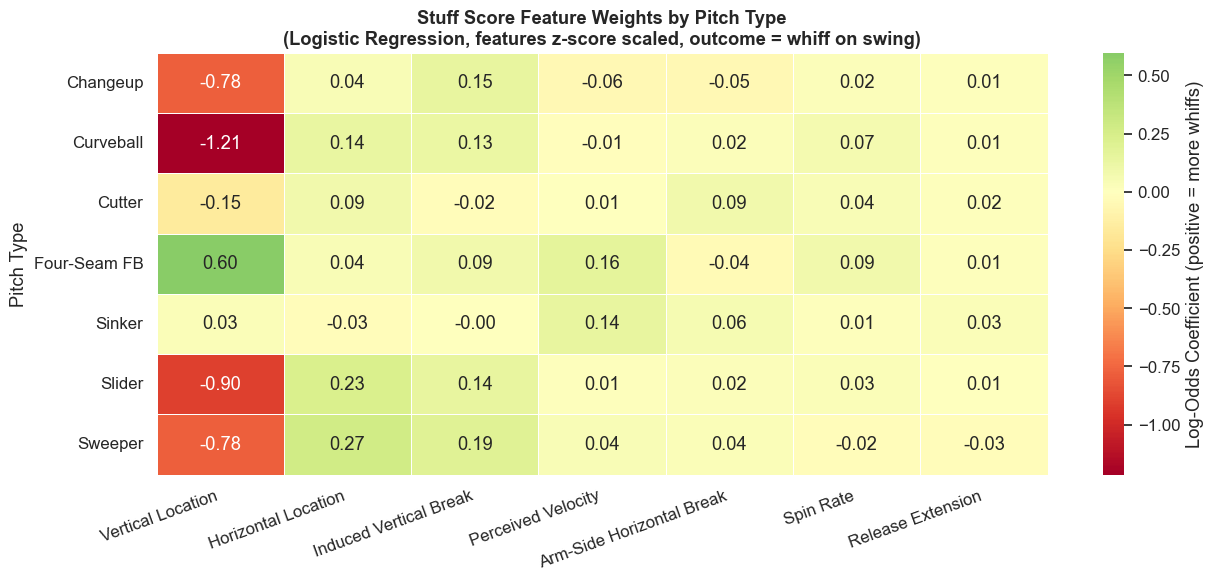

Saved: stuff_coef_heatmap.png


In [20]:
# Normalized coefficient heatmap: how much each feature matters per pitch type
coef_pivot = (
    coef_all[coef_all['pitch_group'].isin(top_groups)]
    .pivot(index='pitch_group', columns='feature_label', values='coefficient')
)

# Order columns by overall abs importance
col_order = coef_pivot.abs().mean().sort_values(ascending=False).index
coef_pivot = coef_pivot[col_order]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    coef_pivot,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Log-Odds Coefficient (positive = more whiffs)'}
)
ax.set_title('Stuff Score Feature Weights by Pitch Type\n'
             '(Logistic Regression, features z-score scaled, outcome = whiff on swing)',
             fontweight='bold')
ax.set_ylabel('Pitch Type')
ax.set_xlabel('')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('stuff_coef_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: stuff_coef_heatmap.png')

## 12. Summary: Key Findings

This cell summarizes the main takeaways.

In [21]:
# Print a clean summary of the model and key findings
print('='*70)
print('  STUFF+ MODEL SUMMARY (2023–2025 Statcast, Pitch-Level Analysis)')
print('='*70)

print('\n--- Model Performance (AUC: predict whiff on swing, 5-fold CV) ---')
for pg in sorted(cv_aucs, key=cv_aucs.get, reverse=True):
    print(f'  {pg:20s}: AUC = {cv_aucs[pg]:.3f}')

print('\n--- Key Feature Findings (Four-Seam Fastball) ---')
fb_coefs = coef_all[coef_all['pitch_group'] == FOCUS_PITCH].sort_values('coefficient', ascending=False)
for _, row in fb_coefs.iterrows():
    direction = '↑ whiffs' if row['coefficient'] > 0 else '↓ whiffs'
    print(f'  {row["feature_label"]:30s}: {row["coefficient"]:+.3f}  ({direction})')

print('\n--- Arsenal Stuff+ Leaders ({}):'.format(max_season))
top10 = qual_arsenal.sort_values('arsenal_stuff', ascending=False).head(10)
for _, row in top10.iterrows():
    print(f'  {row["player_name"]:25s}: Stuff+ = {row["arsenal_stuff"]:.1f} | '
          f'Whiff% = {row["whiff_rate"]:.1%} | xwOBA = {row["avg_xwoba"]:.3f}')

print('\n--- Stuff+ vs Outcome Correlations (pitcher-season level) ---')
corr_whiff = pitcher_qual['stuff_plus_mean'].corr(pitcher_qual['whiff_rate'])
corr_xwoba = pitcher_qual['stuff_plus_mean'].corr(pitcher_qual['avg_xwoba'])
corr_csw   = pitcher_qual['stuff_plus_mean'].corr(pitcher_qual['csw_rate'])
print(f'  Stuff+ vs Whiff Rate: r = {corr_whiff:.3f}')
print(f'  Stuff+ vs xwOBA:      r = {corr_xwoba:.3f}')
print(f'  Stuff+ vs CSW Rate:   r = {corr_csw:.3f}')

print('\n--- Output Files ---')
for f in [
    'pitch_type_outcomes.png', 'stuff_coefficients.png',
    'stuff_plus_distribution.png', 'stuff_plus_vs_outcomes.png',
    'top_pitchers_stuff.png', 'pitcher_stuff_vs_outcomes.png',
    'shap_bar_4seam.png', 'shap_beeswarm_4seam.png',
    'shap_dependence_4seam.png', 'pitcher_shap_breakdown.png',
    'stuff_coef_heatmap.png', 'radar_top3.html'
]:
    print(f'  {f}')
print('='*70)

  STUFF+ MODEL SUMMARY (2023–2025 Statcast, Pitch-Level Analysis)

--- Model Performance (AUC: predict whiff on swing, 5-fold CV) ---
  Knuckle-Curve       : AUC = 0.819
  Curveball           : AUC = 0.779
  Splitter            : AUC = 0.743
  Slider              : AUC = 0.735
  Sweeper             : AUC = 0.709
  Changeup            : AUC = 0.697
  Four-Seam FB        : AUC = 0.673
  Cutter              : AUC = 0.550
  Sinker              : AUC = 0.542

--- Key Feature Findings (Four-Seam Fastball) ---
  Vertical Location             : +0.598  (↑ whiffs)
  Perceived Velocity            : +0.164  (↑ whiffs)
  Spin Rate                     : +0.087  (↑ whiffs)
  Induced Vertical Break        : +0.085  (↑ whiffs)
  Horizontal Location           : +0.044  (↑ whiffs)
  Release Extension             : +0.014  (↑ whiffs)
  Arm-Side Horizontal Break     : -0.043  (↓ whiffs)

--- Arsenal Stuff+ Leaders (2025):
  Bautista, Félix          : Stuff+ = 117.8 | Whiff% = 35.7% | xwOBA = 0.264
  Chapm